Traitement des images

In [1]:
import sys
print(sys.executable)

c:\Users\Invite\AppData\Local\Programs\Python\Python313\python.exe


In [39]:
from PIL import Image
import os
import numpy as np
from skimage import filters, morphology, exposure, util, color
from skimage.filters import threshold_otsu
from skimage import filters, morphology, exposure
from skimage.restoration import denoise_bilateral
from skimage.segmentation import active_contour
from scipy.ndimage import binary_fill_holes, gaussian_filter1d
import cv2
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray

In [ ]:
# def _to_gray_float(image):
#     """
#     Convertit une image PIL ou numpy en niveaux de gris float [0,1].
#     Gère les images RGB, RGBA, et déjà en niveaux de gris.
#     """
#     if isinstance(image, Image.Image):
#         # Si l'image a un canal alpha, on le retire
#         if image.mode == "RGBA":
#             image = image.convert("RGB")
#         # Convertit en niveaux de gris
#         arr = np.array(image.convert('L'))
#     else:
#         arr = np.asarray(image)
#         if arr.ndim == 3:
#             # Si l'image a un canal alpha, on le retire
#             if arr.shape[2] == 4:
#                 arr = arr[..., :3]
#             arr = color.rgb2gray(arr)
#     # Normalise en float [0,1]
#     arr_float = util.img_as_float(arr)
#     return arr_float

def crop_image(input_path, output_path, pad=30):
    """Croppe un cadre de `pad` pixels autour de l'image et sauvegarde le résultat."""
    img = Image.open(input_path)
    width, height = img.size
    left, top = pad, pad
    right, bottom = width - pad, height - pad
    cropped_img = img.crop((left, top, right, bottom))
    cropped_img.save(output_path)
    

In [42]:
def preprocess_image(image):
    """
    Étape 1 : Prétraitement
    - Denoising bilatéral pour réduire le bruit tout en préservant les contours
    - Egalisation d'histogramme pour améliorer le contraste
    """
    denoised = denoise_bilateral(image, sigma_color=0.05, sigma_spatial=15, channel_axis=None)
    equalized = exposure.equalize_hist(denoised)
    return equalized

def threshold_by_second_derivative(image, mask=None, bins=256, smooth_sigma=2, min_pixels=50, debug=False):
    """
    Calcule un seuil en analysant la dérivée seconde de l'histogramme des intensités.
    - image : image float [0,1]
    - mask : bool array (si None, utilise toute l'image)
    - bins : nombre de bins pour l'histogramme
    - smooth_sigma : sigma pour le lissage gaussien de l'histogramme
    Retourne le seuil (valeur d'intensité).
    """
    if mask is None:
        pixels = image.ravel()
    else:
        pixels = image[mask]
    if pixels.size < min_pixels:
        return 0.0
    hist, edges = np.histogram(pixels, bins=bins, range=(0.0, 1.0), density=True)
    centers = (edges[:-1] + edges[1:]) / 2.0
    # Lissage
    hist_s = gaussian_filter1d(hist, sigma=smooth_sigma)
    # Dérivée seconde (approx numérique)
    dx = centers[1] - centers[0]
    second = np.gradient(np.gradient(hist_s, dx), dx)
    # Cherche l'indice de la concavité la plus négative (chute la plus marquée)
    idx = np.argmin(second)
    thresh = centers[idx]
    if debug:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(8,3))
        plt.subplot(1,3,1); plt.plot(centers, hist, label='hist'); plt.title('hist'); plt.axvline(thresh,color='r')
        plt.subplot(1,3,2); plt.plot(centers, hist_s, label='smoothed'); plt.title('smoothed')
        plt.subplot(1,3,3); plt.plot(centers, second, label='2nd deriv'); plt.title('2nd deriv'); plt.axvline(thresh,color='r')
        plt.tight_layout(); plt.show()
    return float(thresh)


def otsu_threshold(image):
    """
    Étape 2 : Seuillage par méthode d'Otsu pour segmenter la région du sein.
    """
    thresh = filters.threshold_otsu(image)
    binary_mask = image > thresh
    # Nettoyage morphologique pour enlever petits objets
    clean_mask = morphology.remove_small_objects(binary_mask, min_size=500)
    clean_mask = morphology.remove_small_holes(clean_mask, area_threshold=500)
    return clean_mask

# Intégration dans la pipeline : après Otsu, calculer le seuil et mettre à zéro les pixels plus faibles
def pipeline_mammography_segmentation(image):
    """
    Pipeline complète de segmentation, avec seuillage par dérivée seconde
    pour fixer les pixels trop faibles à 0.
    """
    preproc = preprocess_image(image)
    otsu_mask = otsu_threshold(preproc)
    # calculer seuil sur la région du sein trouvée par Otsu
    thresh = threshold_by_second_derivative(preproc, mask=otsu_mask, bins=256, smooth_sigma=2)
    preproc_thresh = preproc.copy()
    preproc_thresh[preproc_thresh < thresh] = 0.0
    # continuer avec la version seuillée
    li_mask = refine_li_threshold(preproc_thresh, otsu_mask)
    microcalc_mask = detect_microcalcifications(preproc_thresh, li_mask)
    return {
        "preprocessed": preproc_thresh,
        "breast_region": otsu_mask,
        "refined_region": li_mask,
        "microcalcifications": microcalc_mask,
        "second_derivative_threshold": thresh
    }

def refine_li_threshold(image, mask):
    """
    Étape 3 : Affiner le masque avec un seuillage Li sur la région d’intérêt
    """
    roi = image * mask
    # Extraire uniquement les pixels à l’intérieur du masque
    pixels_roi = roi[mask]
    thresh_li = filters.threshold_li(pixels_roi)
    refined_mask = roi > thresh_li
    # Morphologie pour combler les trous et lisser
    refined_mask = morphology.binary_closing(refined_mask, morphology.disk(3))
    refined_mask = binary_fill_holes(refined_mask)
    return refined_mask

def detect_microcalcifications(image, mask):
    """
    Étape 4 : Détection des micro-calcifications : ici on applique un seuillage  
    sur le masque affiné pour isoler les calcifications denses.
    """
    # Seuillage haute intensité (peut être ajusté)
    high_thresh = 0.7  # seuil à ajuster selon l'image
    microcalc_mask = (image > high_thresh) & mask
    # Nettoyage morphologique pour isoler petits foyers
    microcalc_mask = morphology.remove_small_objects(microcalc_mask, min_size=5)
    return microcalc_mask

def pipeline_mammography_segmentation(image):
    """
    Pipeline complète de segmentation inspirée de la thèse
    """
    preproc = preprocess_image(image)
    otsu_mask = otsu_threshold(preproc)
    li_mask = refine_li_threshold(preproc, otsu_mask)
    microcalc_mask = detect_microcalcifications(preproc, li_mask)
    return {
        "preprocessed": preproc,
        "breast_region": otsu_mask,
        "refined_region": li_mask,
        "microcalcifications": microcalc_mask
    }


c:\Users\Invite\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


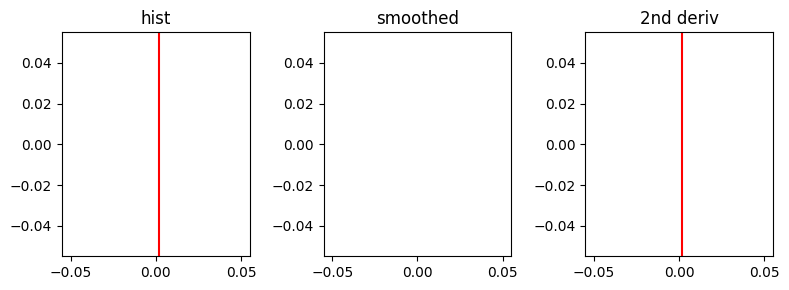

Seuil (dérivée seconde) = 0.0020


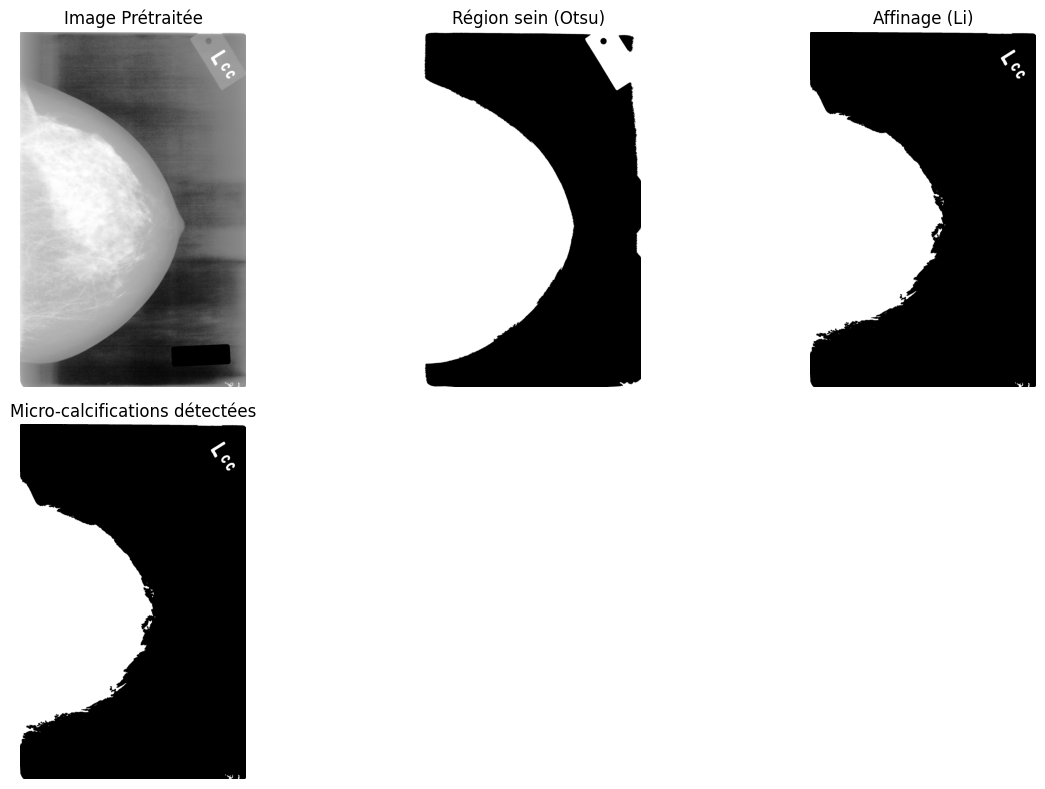

In [ ]:
# Charger une image mammographique en niveau de gris et appliquer la pipeline
image_path = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC.png"
image = imread(image_path)

# Si l'image est en couleur (RGB), la convertir en niveaux de gris
if image.ndim == 3:
    image = rgb2gray(image)

# Normaliser les pixels entre 0 et 1 si nécessaire et assurer float
image = image.astype(np.float32)
if image.max() > 1.0:
    image = image / 255.0

# Option debug pour afficher l'histogramme + dérivée seconde
show_debug = True

# calcule le seuil séparément (affiche le diagnostic si demandé)
thresh = threshold_by_second_derivative(image, mask=None, bins=256, smooth_sigma=2, debug=show_debug)
print(f"Seuil (dérivée seconde) = {thresh:.4f}")

# Appliquer la pipeline complète de segmentation (qui utilise ou non ce seuil selon implémentation)
results = pipeline_mammography_segmentation(image)

# Si la pipeline retourne le seuil calculé, l'afficher
if "second_derivative_threshold" in results:
    print("Seuil retourné par la pipeline:", results["second_derivative_threshold"])

# Afficher les résultats intermédiaires et finaux
plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.title("Image Prétraitée")
plt.imshow(results["preprocessed"], cmap="gray")
plt.axis("off")

plt.subplot(232)
plt.title("Région sein (Otsu)")
plt.imshow(results["breast_region"], cmap="gray")
plt.axis("off")

plt.subplot(233)
plt.title("Affinage (Li)")
plt.imshow(results["refined_region"], cmap="gray")
plt.axis("off")

plt.subplot(234)
plt.title("Micro-calcifications détectées")
plt.imshow(results["microcalcifications"], cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

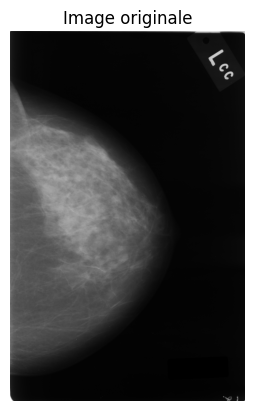

<class 'PIL.PngImagePlugin.PngImageFile'> (1464, 2304) I;16


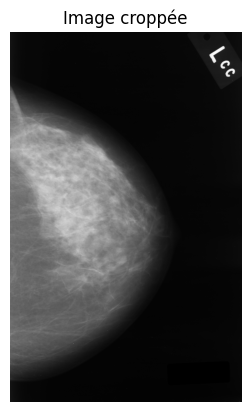

In [ ]:
# Charge ton image
img = Image.open("C:\\Users\\Invite\\Documents\\INRIA\\MCDropout\\archive\\MINI-DDSM-Complete-PNG-16\\Cancer\\0001\\C_0001_1.LEFT_CC.png")
img_np = np.array(img) 

plt.imshow(img, cmap='gray')
plt.title("Image originale")
plt.axis('off')
plt.show()
print(type(img), img.size, img.mode)

input_path = "C:\\Users\\Invite\\Documents\\INRIA\\MCDropout\\archive\\MINI-DDSM-Complete-PNG-16\\Cancer\\0001\\C_0001_1.LEFT_CC.png"
output_path = "C_0001_1.LEFT_CC_cropped.png"
crop_image(input_path, output_path)
img_cropped = Image.open(output_path)
plt.imshow(img_cropped, cmap='gray')
plt.title("Image croppée")
plt.axis('off')
plt.show()

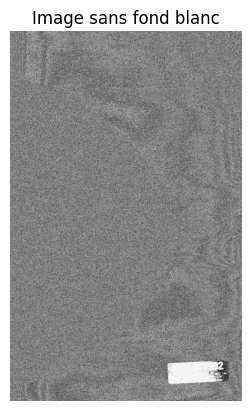

In [26]:
def set_background_to_zero(img):
    """
    Détecte les pixels de fond (255/blanc) et les met à 0 (noir).
    Accepte une image PIL ou un array numpy.
    """
    if isinstance(img, Image.Image):
        arr = np.array(img)
    else:
        arr = img
    arr_bg_zero = arr.copy()
    arr_bg_zero[arr == 255] = 0
    return Image.fromarray(arr_bg_zero.astype(np.uint8), mode='L')

img_no_bg = set_background_to_zero(img_cropped)
plt.imshow(img_no_bg, cmap='gray')
plt.title("Image sans fond blanc")
plt.axis('off')
plt.show()